# Convert PyTorch weights to Flax and locate numerical errors

CPU companion; no accelerator is required. TPU execution not validated.

- Map named PyTorch tensors into Flax NNX parameters with complete key, shape and dtype checks.
- Locate the first mismatching operation using absolute and relative errors.
- Verify input gradients and reload the converted artifact independently.

You copied a checkpoint and the new model runs, but its answers differ. Is the weight mapping wrong, or does the architecture compute a different function? We will load actual PyTorch tensors into a Flax NNX model and stop at the first layer whose values diverge.

## The idea

Numerical parity is an architecture audit, not a file-format check. Match the input contract and every operation, compare intermediate activations with explicit error budgets, then verify gradients and reloaded-artifact outputs. This lab converts a dense–LayerNorm–exact-GELU–dense network on CPU; it is not a universal checkpoint converter.

## Write the architecture contract before mapping weights

Our input has shape $(B,3)$, the hidden width is $5$, and the output width is $2$. PyTorch Linear stores output-by-input weights, while Flax Linear uses input-by-output kernels, so transpose those two arrays. LayerNorm scale and bias stay one-dimensional and do not transpose. Require every expected key exactly once; ignoring unknown or missing parameters can silently leave random weights in the target.

## Match operations, not just tensors

Use the same LayerNorm epsilon, feature axes, variance convention and affine parameters. Select exact GELU in both frameworks instead of mixing exact and tanh approximations. Disable training-only behavior and match preprocessing, padding, positions and output labels before claiming parity. The Flax implementation disables the fast variance formula to make the comparison boundary explicit; float32 execution can still differ slightly across kernels.

## Use an error budget that works near zero

For each element, require the absolute difference to fit an absolute tolerance plus a relative tolerance times the reference magnitude. Absolute tolerance handles near-zero references; relative tolerance scales with large values. Report maximum absolute error and relative L2 error, but retain the elementwise decision so a small aggregate cannot hide a bad element. Set tolerances before inspecting the candidate, record dtype/backend, and never turn NaN into a passing comparison.

$$
|y_i-\widehat y_i|\leq a+r|y_i|,\qquad e_{\mathrm{rel},2}=\frac{\|y-\widehat y\|_2}{\max(\|y\|_2,10^{-12})}
$$

## Find the first mismatch

Capture hidden linear output, normalized values, activation and final logits for the same inputs. A wrong LayerNorm epsilon leaves the hidden linear output correct but changes the normalized output first. Later mismatches may be consequences rather than separate bugs. Use several batch sizes and amplitudes: one large random batch can miss epsilon-sensitive or near-zero behavior.

## Validate the derivative and the saved artifact

For a scalar sum of outputs, compare gradients with respect to the input in both frameworks. Then save the Flax arrays with architecture metadata and reload them before inference. The project also starts a fresh process for this step. Only load trusted checkpoint sources; weights_only loading limits the PyTorch loading path but does not establish authenticity or universal safety.

## Extend the mapping deliberately

Convolution kernels may require OIHW to HWIO permutations, not a dense transpose. Attention may fuse query/key/value tensors or arrange heads differently. Tied embeddings, normalization order, rotary positions and vocabulary row order can all change behavior despite matching shapes. Add these operations one at a time with golden inputs and intermediate comparisons. This lesson validates its named MLP only; those additional architectures need their own executed mappings.

## Run the example

In [1]:
"""Explicit CPU PyTorch -> Flax NNX mapping; no generic architecture converter."""
import numpy as np
import jax
import jax.numpy as jnp
import torch
from flax import nnx

class TorchModel(torch.nn.Module):
    def __init__(self, eps=1e-5):
        super().__init__()
        self.hidden=torch.nn.Linear(3,5)
        self.norm=torch.nn.LayerNorm(5,eps=eps)
        self.out=torch.nn.Linear(5,2)
    def forward(self,x):
        h=self.hidden(x);n=self.norm(h);a=torch.nn.functional.gelu(n,approximate='none')
        return {'hidden':h,'norm':n,'activation':a,'output':self.out(a)}

class FlaxModel(nnx.Module):
    def __init__(self,eps=1e-5):
        self.hidden=nnx.Linear(3,5,rngs=nnx.Rngs(0))
        self.norm=nnx.LayerNorm(5,epsilon=eps,use_fast_variance=False,rngs=nnx.Rngs(1))
        self.out=nnx.Linear(5,2,rngs=nnx.Rngs(2))
    def __call__(self,x):
        h=self.hidden(x);n=self.norm(h);a=jax.nn.gelu(n,approximate=False)
        return {'hidden':h,'norm':n,'activation':a,'output':self.out(a)}

def convert(state,eps=1e-5):
    shapes={'hidden.weight':(5,3),'hidden.bias':(5,),'norm.weight':(5,),'norm.bias':(5,),'out.weight':(2,5),'out.bias':(2,)}
    if set(state)!=set(shapes):raise ValueError('missing or unexpected state key')
    arrays={}
    for name,shape in shapes.items():
        value=state[name].detach().cpu().numpy()
        if value.shape!=shape or value.dtype!=np.float32 or not np.isfinite(value).all():
            raise ValueError('unexpected shape, dtype or nonfinite tensor: '+name)
        arrays[name]=value.copy()
    target=FlaxModel(eps)
    target.hidden.kernel[...]=jnp.asarray(arrays['hidden.weight'].T)
    target.hidden.bias[...]=jnp.asarray(arrays['hidden.bias'])
    target.norm.scale[...]=jnp.asarray(arrays['norm.weight'])
    target.norm.bias[...]=jnp.asarray(arrays['norm.bias'])
    target.out.kernel[...]=jnp.asarray(arrays['out.weight'].T)
    target.out.bias[...]=jnp.asarray(arrays['out.bias'])
    return target

def error_report(reference,actual,atol=2e-6,rtol=2e-5):
    reference=np.asarray(reference,dtype=np.float64);actual=np.asarray(actual,dtype=np.float64)
    if reference.shape!=actual.shape or not np.isfinite(reference).all() or not np.isfinite(actual).all():
        raise ValueError('shape or finite-value mismatch')
    if min(atol,rtol)<0 or not np.isfinite([atol,rtol]).all():raise ValueError('invalid tolerances')
    absolute=np.abs(actual-reference)
    budget=atol+rtol*np.abs(reference)
    return {'max_abs':float(absolute.max()),'relative_l2':float(np.linalg.norm(actual-reference)/max(np.linalg.norm(reference),1e-12)),
            'passed':bool(np.all(absolute<=budget))}

def save_flax(model,path):
    np.savez(path,hidden_kernel=np.asarray(model.hidden.kernel[...]),hidden_bias=np.asarray(model.hidden.bias[...]),
             norm_scale=np.asarray(model.norm.scale[...]),norm_bias=np.asarray(model.norm.bias[...]),
             out_kernel=np.asarray(model.out.kernel[...]),out_bias=np.asarray(model.out.bias[...]),
             epsilon=np.array(model.norm.epsilon),schema=np.array(1))

def load_flax(path):
    shapes={'hidden_kernel':(3,5),'hidden_bias':(5,),'norm_scale':(5,),'norm_bias':(5,),'out_kernel':(5,2),'out_bias':(2,)}
    with np.load(path,allow_pickle=False) as archive:
        if set(archive.files)!=set(shapes)|{'epsilon','schema'}:raise ValueError('unexpected archive schema')
        if archive['schema'].shape!=() or int(archive['schema'])!=1:raise ValueError('unknown schema')
        if archive['epsilon'].shape!=():raise ValueError('epsilon must be scalar')
        eps=float(archive['epsilon'])
        if not np.isfinite(eps) or eps<=0:raise ValueError('invalid epsilon')
        arrays={}
        for key,shape in shapes.items():
            value=archive[key]
            if value.shape!=shape or value.dtype!=np.float32 or not np.isfinite(value).all():raise ValueError('invalid array '+key)
            arrays[key]=value.copy()
    model=FlaxModel(eps)
    for module,name,key in [(model.hidden,'kernel','hidden_kernel'),(model.hidden,'bias','hidden_bias'),(model.norm,'scale','norm_scale'),(model.norm,'bias','norm_bias'),(model.out,'kernel','out_kernel'),(model.out,'bias','out_bias')]:
        getattr(module,name)[...]=jnp.asarray(arrays[key])
    return model

import tempfile
from pathlib import Path
torch.set_num_threads(1)
torch.manual_seed(9)
source=TorchModel().eval()
# A real local state_dict file, loaded using the tensor-only loading option.
with tempfile.TemporaryDirectory() as folder:
    checkpoint=Path(folder)/'weights.pt';torch.save(source.state_dict(),checkpoint)
    state=torch.load(checkpoint,map_location='cpu',weights_only=True)
    target=convert(state)
    # Save the converted weights independently of the live PyTorch object.
    converted=Path(folder)/'flax-weights.npz'
    save_flax(target,converted)
    target=load_flax(converted)
    errors={name:[] for name in ['hidden','norm','activation','output']}
    for batch,scale in [(1,1.),(7,1e-3),(5,4.)]:
        inputs=np.random.default_rng(batch).normal(size=(batch,3)).astype(np.float32)*scale
        tx=torch.tensor(inputs,requires_grad=True);torch_values=source(tx);flax_values=target(jnp.asarray(inputs))
        for name in errors:
            report=error_report(torch_values[name].detach().numpy(),flax_values[name]);assert report['passed'],(name,report)
            errors[name].append(report['max_abs'])
        torch_values['output'].sum().backward()
        input_gradient=jax.grad(lambda z:jnp.sum(target(z)['output']))(jnp.asarray(inputs))
        assert error_report(tx.grad.numpy(),input_gradient,atol=5e-6,rtol=5e-5)['passed']
    wrong=convert(state,eps=.1)
    reference={k:v.detach().numpy() for k,v in source(torch.tensor(inputs)).items()}
    wrong_reports={k:error_report(reference[k],v) for k,v in wrong(jnp.asarray(inputs)).items()}
    assert wrong_reports['hidden']['passed'] and not wrong_reports['norm']['passed']
    for bad in [dict(state,unexpected=torch.zeros(1)),{k:v for k,v in state.items() if k!='norm.bias'}]:
        try:convert(bad)
        except ValueError:pass
        else:raise AssertionError('incomplete mapping accepted')
print('Maximum absolute error per layer:',{k:max(v) for k,v in errors.items()})
print('Wrong epsilon: first mismatch is norm; intermediate outputs and input gradients verified on CPU.')


Maximum absolute error per layer: {'hidden': 2.384185791015625e-07, 'norm': 3.5762786865234375e-07, 'activation': 3.5762786865234375e-07, 'output': 1.1920928955078125e-07}
Wrong epsilon: first mismatch is norm; intermediate outputs and input gradients verified on CPU.


Expected: Correct FP32 conversion passes layerwise and input-gradient tolerances on three input regimes. A changed LayerNorm epsilon first fails at norm; missing and unexpected keys are rejected.

## Locate the first divergent layer

Predict: Which bar should remain near zero when only LayerNorm epsilon is wrong?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [2]:
visual_data={'kind':'bar','labels':list(errors),'xlabel':'operation in execution order','ylabel':'maximum absolute output error','series':[{'label':'matched architecture (max across inputs)','y':[max(v) for v in errors.values()]},{'label':'wrong epsilon (last input batch)','y':[wrong_reports[k]['max_abs'] for k in errors]}]}

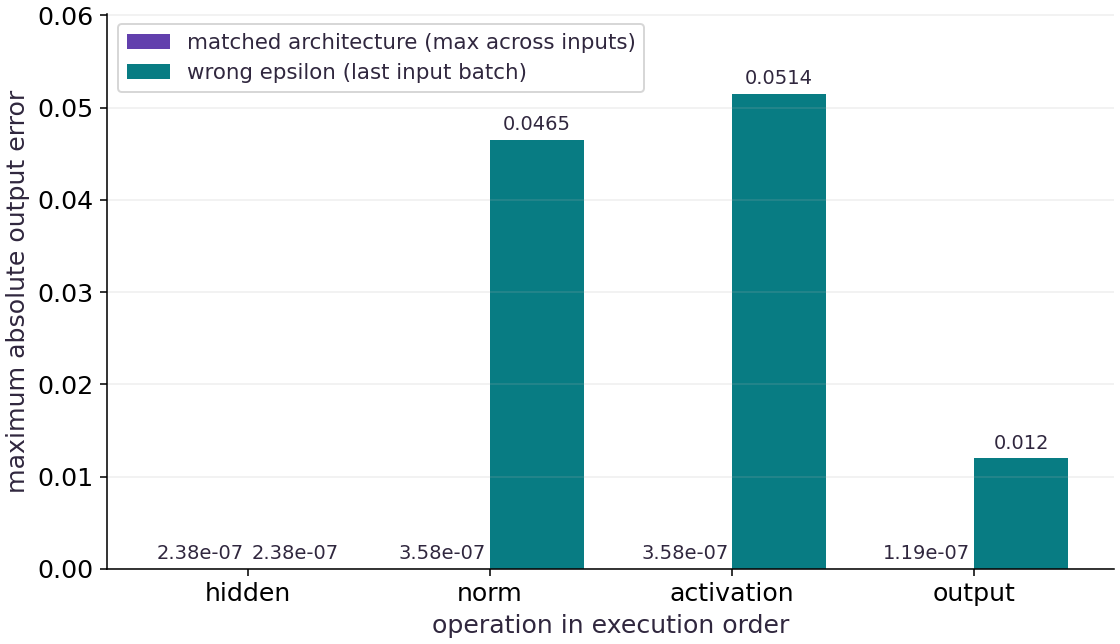

In [3]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data['unit'] in ('attention weight', 'next-token probability'):
            kw.update(vmin=0, vmax=1)
        device_ids = 'device ID' in data['unit']
        if device_ids:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            ids=np.unique(a).astype(int)
            kw.update(cmap=ListedColormap(palette[:len(ids)]), norm=BoundaryNorm(np.arange(ids.min()-0.5,ids.max()+1.5),len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if device_ids else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories follow execution order: hidden linear, normalization, activation and output. Bars show maximum absolute difference in that layer’s output units. The correct mapping remains near floating-point rounding error; the changed-epsilon model first diverges at normalization. The earlier matching hidden output narrows the cause. These are numerical errors, not accuracy or latency.

### Connect it to the computation

All weights are identical between the correct and wrong-epsilon target models. A parameter-file comparison alone would miss the changed operation. Later error may grow or shrink through nonlinearities and the output projection, so the largest bar is not necessarily the location of the original bug. The per-element tolerance and gradient checks are reported separately from this plot.

## Inspect the wrong-epsilon signature

Predict: Will the dense hidden output fail when only normalization epsilon changes?

In [4]:
assert wrong_reports['hidden']['passed']
assert not wrong_reports['norm']['passed']
print('Per-layer wrong-epsilon report:',wrong_reports)

Per-layer wrong-epsilon report: {'hidden': {'max_abs': 2.384185791015625e-07, 'relative_l2': 3.5662515782829134e-08, 'passed': True}, 'norm': {'max_abs': 0.046508073806762695, 'relative_l2': 0.018277932316979384, 'passed': False}, 'activation': {'max_abs': 0.05144989490509033, 'relative_l2': 0.022399576976497533, 'passed': False}, 'output': {'max_abs': 0.011958837509155273, 'relative_l2': 0.013684121610437203, 'passed': False}}


Expected: The first dense layer passes; normalization fails first.

Localize the first divergent operation before remapping unrelated weights. The plot records downstream effects as well as the first failure.

## Your exercise

Compare a near-zero reference against two candidate errors. Verify that the absolute tolerance accepts rounding noise but rejects a meaningful discrepancy.

In [5]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [6]:
assert error_report([0.,1.],[1e-7,1.000001])['passed']
assert not error_report([0.,1.],[1e-3,1.])['passed']
print('Near-zero acceptance and rejection verified.')

Near-zero acceptance and rejection verified.


## Reject a plausible but wrong tensor layout · Transfer

Transpose the first PyTorch weight before conversion and prove the boundary rejects it instead of transposing it a second time.

Hint: The first weight is rectangular, so validate its source shape before applying the mapping.

In [7]:
# Write your attempt here.

## Reference reasoning

Asymmetric dimensions expose orientation errors that square test matrices can hide. Shape checks complement numerical checks rather than replacing them.

In [8]:
bad_state=dict(state);bad_state['hidden.weight']=state['hidden.weight'].T
try:convert(bad_state)
except ValueError:print('Wrong source layout rejected')
else:raise AssertionError('layout mismatch accepted')

Wrong source layout rejected


## Checkpoint

The first linear layer agrees, but LayerNorm is the first mismatch. What should you inspect next?

1. Normalization axes, variance calculation, epsilon and affine parameters.
2. Relax every tolerance until the final outputs pass.
3. Assume successful checkpoint loading proves parity.

## Diagnose

Reject missing, extra, malformed or nonfinite weights before assignment. If the first linear output differs, inspect orientation and bias. If normalization first differs, inspect its contract. If forward outputs agree but gradients differ, inspect operation approximations and differentiability; retain both results.

## Evidence

Keep source checkpoint and architecture identity, complete parameter mapping, per-layer max-absolute/relative-L2 errors, elementwise tolerances, input-gradient comparisons, wrong-epsilon diagnosis and a fresh-process converted-artifact receipt.

## Primary references

- [PyTorch state_dict and weights-only loading](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
- [Flax NNX Linear](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/nn/linear.html)